# The rescaling Gross-Pitaevskii equation

In cold-atomic BEC experiments, the quintessential experiment is the time-of-flight measurement. Releasing an atomic cloud then imaging its density profile allows the determination of various important quantities such as the temperature, interaction strength or momentum distribution. This apparently simple experiment can prove surprisingly hard o solve numerically. Indeed, the issue arising quickly in this situation is the rapidly expanding size of the cloud: How then can we keep the cloud inside the simulation box until it as sufficiently evolved ? 

One could simply take a very large simulation box, in that case, the initial condensate, in the center, can expand freely for quite some time before reaching the edges of the box. However, this leads to a complication: The initial condensate, occupying only a very small fraction of the simulation box, might not be sufficiently resolved numerically. One then as to match this large box with a correspondingly large numerical resolution, wich obviously leads to a much heavier computational load.

Here, we present a solution developped by [A. Bradley et al.](https://doi.org/10.1103/PhysRevA.106.053316), which consists in creating a scaling coordinate system in which the BEC keeps a constant size. We will first present the basic principles of the method, before demonstrating its implementation in the `rSSFM` class.

## General theory

The Gross-Pitaevskii equation, or non-linear Schrödinger equation, governs the dynamics of a BEC wavefunction $\psi(x_i, t)$ where $x_i$ are the spatial coordinates in the laboratory frame and $t$ is the time. The main idea of Bradley et al. is to reformulate the equation in the new coordinates $\rho_i$ defined by $x_i = \lambda_i(t) \rho_i$ where the $\lambda_i$ are time-dependant scaling coefficients to be determined. The equation to solve concerns now the modified wavefunction $\phi(\rho_i,t)$ and scaling coefficients $\lambda_i$. Taking a normalised wavefunction $\phi$, this modified equation reads in 2D, using Einstein summation convention for repeating (bottom/top) indices:

$$
\frac{d\lambda_i}{dt} = \sigma_i(t) \\ \: \\
\frac{d\sigma_i}{dt} = \frac{1}{\lambda_i(t)^2 m a_i^2} \int d^2\rho \left( \frac{g N}{2} \frac{|\phi|^4}{\bar{\lambda}(t)^2} - |\phi|^2 \rho_i \partial_i V(\lambda_i(t)\rho_i,t) + \frac{\hbar^2}{m\lambda_i(t)^2} |\partial_i\phi|^2 \right) \\ \: \\
i\hbar\frac{\partial\phi}{\partial t} = \left(-\frac{\hbar}{2m\lambda^i(t)^2}\partial_i + g N \frac{|\phi|^2}{\bar{\lambda}(t)^2} + V(\lambda_i(t)\rho_i,t) +  \frac{m}{2} \dot{\sigma}(t)\lambda^i(t) \rho_i \rho^i  \right) \phi
$$

where g is the interaction strength, N the number of particles, m the mass of the particles, V is an arbitrary external potential, $\bar{\lambda}$ is the geometric mean of the $\lambda_i$, and a_i is the initial wavepacket characteristic size:

$$a_i^2 = \int d^2 x x_i^2 |\psi(x_i, t = 0)|^2$$

The initial conditions for this system of equations are:

$$
\lambda_i(0) = 1 \\ \: \\
\sigma_i(0) = \frac{1}{a_i^2} \int d^2 \rho \rho_i \frac{i\hbar}{2m} (\psi(\rho_i, 0)\partial_i\psi(\rho_i, 0)^* - \psi(\rho_i, 0)^*\partial_i\psi(\rho_i, 0)) \\ \: \\
\phi(\rho_i,0) = \psi(\rho_i,0) \exp\left(-i\frac{\rho_j\rho^j}{2\hbar}\sigma^j(0)\right)
$$

The derivation and in-depth analysis of this set of equations can be found in the original paper, but we can get a rough intuition of its working principle by looking at the extra term in the eqaution governing the evolution of $\phi$. This term, equivalent to an additional time-dependant harmonic potential, is responsible of the size invariance of $\phi(\rho_i,t)$.

Now that we have introduced the equation, we can present the `rSSFM`class implenting it.

## The `rSSFM` class

Th `rSSFM` class (for rescaling Split-Step Fourier Method) solves the above eqautions using a split-step Fourier method with an adaptative step-doubling scheme. It can be used in the exact same manner as the `SSFM` class, but it needs a specific type of Potential object, namely an object of the `AnalyticPotential` class, as the solver must recompute the potential for arbitrary grids on the fly. The `AnalyticPotential` class is explained in more details in the [Microscope tutorial](docs/Microscope.ipynb). Here, we'll use a simple constant potential, and demonstrate the interest of the `rSSFM` class to simulate the time-evolution of a simple gaussian wavepacket, and will compare it to the same packet simulated on a constant grid.


In [10]:
from BECs.rssfm import rSSFM
from BECs.ssfm import SSFM
from BECs.potentialT import AnalyticPotential
from bloch_schrodinger.potential import Potential, create_parameter
from bloch_schrodinger.plotting import plot_eigenvector

import numpy as np


l = 75
n = 2**8

foo = Potential( # Grid for the regular SSFM solver
    unitvecs = [[l,0], [0,l]], resolution = (n,n), v0 = 0
)

foo_analytic = AnalyticPotential(
    unitvecs = [[l/2,0], [0,l/2]], resolution = (n//2,n//2) # We don't need a grid as large for the analytic potential because it is going to be rescaled continuously. Here, we define the grid at t=0
)

sigma_x = create_parameter("sigma_x", np.linspace(4,8,2))
sigma_y = 6

Psi0_c = np.exp(-((foo.x/sigma_x)**2+(foo.y/sigma_y)**2)) # Initial wavepacket for the constant grid
Psi0_c /= (abs(Psi0_c)**2).sum(["a1","a2"])**0.5 * foo.get_dS()**0.5 # Normalizing the wavefunction

Psi0_r = np.exp(-((foo_analytic.x/sigma_x)**2+(foo_analytic.y/sigma_y)**2)) # Initial wavepacket for the rescaling grid
Psi0_r /= (abs(Psi0_r)**2).sum(["a1","a2"])**0.5 * foo_analytic.get_dS()**0.5 # Normalizing the wavefunction


g = create_parameter("g", np.linspace(0,10,2)) # Taking a few values for the interaction strength
# Initialisation of the solvers, using the same parameters
bar = SSFM(foo, Psi0_c, g) 
bar_rescaling = rSSFM(foo_analytic, Psi0_r, g)

ti = 0
tf = 100
t_samples = create_parameter("t", np.linspace(ti,tf,100)) # Sampling 100 points in time

Psi_c = bar.solve(
    t_init=ti,
    t_final=tf,
    t_samples=t_samples,
    parallelize=True, # Using parallel speed-up
    n_cores = 4
)

Psi_r = bar_rescaling.solve( # the sover for rSSFM is called exactly like for SSFM
    t_init=ti,
    t_final=tf,
    t_samples=t_samples,
    parallelize=True, # Using parallel speed-up
    n_cores = 4
)


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:   29.7s remaining:   29.7s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:   33.2s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:   10.4s remaining:   10.4s
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:   11.1s finished


We are going to display the results using a dedicated function, `plot_eigenvector_rescaling`, adapted from `plot_eigenvector` but working on rescaling grids.

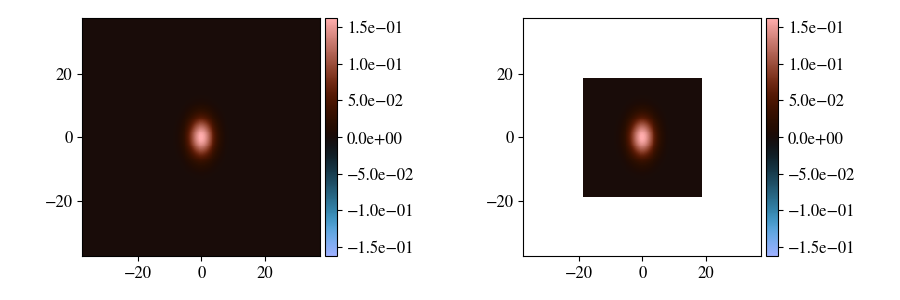

In [11]:
from BECs.plotting import plot_eigenvector_rescaling
import matplotlib.pyplot as plt
%matplotlib widget

fig, axs = plot_eigenvector_rescaling(
    [[Psi_c.real, Psi_r.real]], [[None]*2], [["real"]*2], cst_bds = True
)

# Fixing identical plot limits to easily compare the scales
axs[0][0].set_xlim(-l/2,l/2)
axs[0][1].set_xlim(-l/2,l/2)
axs[0][0].set_ylim(-l/2,l/2)
axs[0][1].set_ylim(-l/2,l/2)

plt.show()

On this one-to-one comparison of the two solvers, one can easily see the advantage of the rescaling coordinate system: The simulation box increases in size with the condensate, thus eliminating the boundary effects and allowing a much tighter (and thus numerically lighter) grid. This more than compensates the slightly longer iteration time-step induced by the additional equations for $\lambda$ and $\sigma$. We can then easily use the new solver to highlight the well-known dispersion inversion occuring in gaussian wavepackets as the ToF is performed:

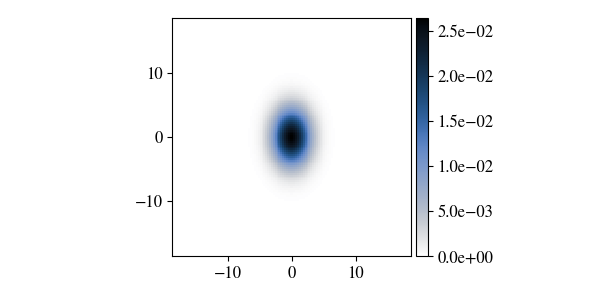

In [12]:
plot_eigenvector_rescaling(
    [[abs(Psi_r)**2]], [[None]], [["amplitude"]]
)
plt.show()

After a certain time t, the wavepacket distribution aspect doesn't change anymore, signifying the full conversion of the real-space to momentum-space.